In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Data1.csv to Data1.csv


In [3]:
#Read exel file
df = pd.read_csv('Data1.csv')
# Display first  rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.duplicated().any()

np.False_

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
#check missing values
df.isnull().any()

,0
CustomerID,False
Gender,False
Age,False
Annual Income (k$),False
Spending Score (1-100),False


In [12]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**Objective:**
The main objective of this study is to develop a Linear Regression model that predicts the customer spending score based on independent variables such as age and annual income.
The study aims to understand the direct linear relationship between customer demographic features and their spending behavior. By identifying how age and annual income influence spending score, businesses can estimate customer purchasing capacity and improve targeted marketing strategies.


In [13]:
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
# Define features (X) and target (y)
X =  df[['Age','Annual Income (k$)']]
y = df['Spending Score (1-100)']

In [15]:
#  Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nTraining Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)


Training Set Size: (160, 2)
Testing Set Size: (40, 2)


In [16]:
#  Model Training
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")


Model Training Completed Successfully!


In [17]:
# Step 6: Model Coefficients "General linear equation: Y=β0+β1X1+β2X2+β3X3+...+βnXn+ε "
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print("\nModel Coefficients:")
print(coeff_df)
print("Intercept:", model.intercept_)


Model Coefficients:
                    Coefficient
Age                   -0.589292
Annual Income (k$)     0.052358
Intercept: 71.53258395331329


In [18]:
# Step : 7 Predictions
y_pred = model.predict(X_test)

In [19]:
# Step 8: Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.3f}")


Model Performance:
Mean Absolute Error (MAE): 18.23
Mean Squared Error (MSE): 483.56
R² Score: 0.020


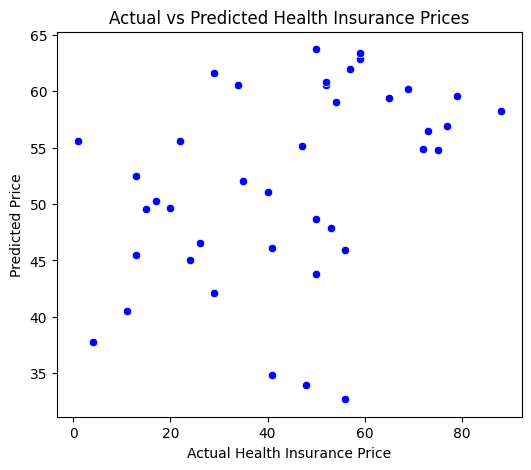

In [20]:
# Step 9: Visualization

# Actual vs Predicted Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred, color="blue")
plt.xlabel("Actual Health Insurance Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Health Insurance Prices")
# Save the graph
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()

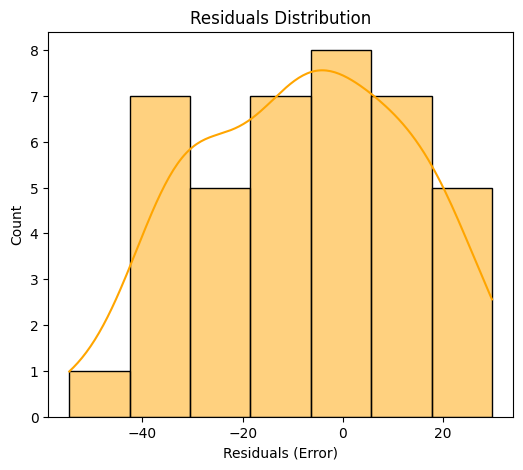

In [21]:
# Residual Plot
plt.figure(figsize=(6, 5))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='orange')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (Error)")

# Save the plot
plt.savefig("residuals_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

**Conclusion**:
The Linear Regression model was developed to predict Customer Spending Score using Age and Annual Income as independent variables.
The model achieved an R² score of 0.020. This indicates  variation in customer spending score is explained by Age and Annual Income. A higher R² value suggests that the model has a stronger ability to explain customer spending behavior
The Mean Squared Error (MSE) value is 483.56. MSE measures the average squared difference between actual and predicted spending scores. A lower MSE indicates better prediction accuracy and lower model error.
Intercept (b₀) = 71.53258395331329
Age Coefficient (b₁) = -0.589292
Annual Income Coefficient (b₂) = 0.052358